### Twitter Sentiment Analysis Lab

#### Dataset (ai2.csv)
The dataset contains approximately 19883 different (scrapped) tweets with the following attributes:
- 'id'         : unique 19 digit id for each tweet
- 'created_at' : date & time of each tweet (or retweet)
- 'text'       : tweet details/ description


#### Objective
- **Sentiment label** - for each tweet based on it's text, devise a method to assign an appropriate sentiment ('positive', 'negative' or 'neutral'). This is achieved by using TextBlob (https://textblob.readthedocs.io/en/dev/)
- **Text Analytics/NLP** - to extract features from tweet texts
- **Machine Learning** - Building a robust & optimized ML model to accurately predict the sentiment associated with each tweet & explanation of the built model

In [139]:
# mount data from Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [149]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/ai2.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19883 entries, 0 to 19882
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          19883 non-null  float64
 1   created_at  19883 non-null  object 
 2   date        19883 non-null  object 
 3   time        19883 non-null  object 
 4   tweet       19883 non-null  object 
dtypes: float64(1), object(4)
memory usage: 776.8+ KB


In [150]:
# Libraries for data preparation & visualisation

import re
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud


# Library to ignore warnings

import warnings
warnings.filterwarnings("ignore")

# Library for assigning sentiment label

from textblob import TextBlob

# Libraries for text analytics

import nltk
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem.porter  import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

# Libraries for ML modeling

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.model_selection import GridSearchCV, cross_val_score #cross-validation
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline #not used today
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

In [151]:
# Shape of data

df.shape

(19883, 5)

- There are 19883 rows & 5 columns

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19883 entries, 0 to 19882
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          19883 non-null  float64
 1   created_at  19883 non-null  object 
 2   date        19883 non-null  object 
 3   time        19883 non-null  object 
 4   tweet       19883 non-null  object 
dtypes: float64(1), object(4)
memory usage: 776.8+ KB


- 'id' is a 16 digit random number associated with each tweet. This should have no relevance on final modeling & can be dropped
- 'created_at' is of object type & will be converted to datetime format
- 'location' has 442 missing records

In [153]:
# Dropping 'id'

df = df.drop('id', axis=1)

In [145]:
# Changing datatype for created_at

df['created_at'] = pd.to_datetime(df['created_at'])

In [154]:
df.describe(include='all').T

,count,unique,top,freq
created_at,19883,18043,2022-08-31 17:06:13 UTC,9
date,19883,3,31/08/2022,9283
time,19883,16551,18:30:00,10
tweet,19883,19513,What can you learn from #AI advances in medica...,16


- 'text' value is repeated in the dataset, e.g., text 'RT @NHLBlackhawks: Staying warm never looked s...' occurs 25 times in the dataset. This indicates some of the texts have retweets

In [155]:
# Checking duplicates

df.duplicated().sum()

5

- There are 5 duplicate records

In [156]:
df = df.drop_duplicates()

In [157]:
df.duplicated().sum()

0

Now we have removed duplicates.

In [158]:
# Checking for missing values

df.isnull().sum().sum()

0

- No further missing values

#### Feature Engineering & EDA

In [159]:
!pip install langdetect

In [160]:
# Language detection

from langdetect import detect

def language_detection(text):

    try:
        language = detect(text)
        return(language)
    except:
        return('error')

df['language'] = df['tweet'].apply(language_detection)

In [161]:
df.head()

,created_at,date,time,tweet,language
0,2022-09-01 10:09:46 UTC,01/09/2022,10:09:46,#workathome #digitalnomad #WFH DevOps Enginee...,en
1,2022-09-01 10:09:42 UTC,01/09/2022,10:09:42,Neurobiology: Wellspring of Machine Learning w...,en
2,2022-09-01 10:08:58 UTC,01/09/2022,10:08:58,Opening for remote Lead Flask Developer with P...,en
3,2022-09-01 10:08:22 UTC,01/09/2022,10:08:22,Bytesview's advanced #textanalysis tools let y...,en
4,2022-09-01 10:08:10 UTC,01/09/2022,10:08:10,#山田太郎 応援中！ ＃山田太郎のさんちゃんねる ＃MIMIC ＃AI ＃著作権 ＃著作人格権,ja


In [162]:
# Language

df['language'].value_counts()

,count
language,
en,17498
ja,1285
fr,200
it,184
es,142
de,76
ca,57
no,53
nl,43


In [163]:
# Filter the dataset to only contain english texts

df = df[df['language']=='en']
df.drop('language', axis=1, inplace=True)

In [164]:
# Shape of data

df.shape

(17498, 4)

- There are 17421 rows remaining

In [166]:
# Ensure 'created_at' is in datetime format
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')  # Converts while handling errors

# Extract day of the week
df['day_of_week'] = df['created_at'].dt.dayofweek

# Map numeric days to actual day names
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_of_week'] = df['day_of_week'].map(day_map)

# Display results
print(df[['created_at', 'day_of_week']].head())


                 created_at day_of_week
0 2022-09-01 10:09:46+00:00    Thursday
1 2022-09-01 10:09:42+00:00    Thursday
2 2022-09-01 10:08:58+00:00    Thursday
3 2022-09-01 10:08:22+00:00    Thursday
5 2022-09-01 10:07:51+00:00    Thursday


In [167]:
# Hour

df['hour']        = df['created_at'].dt.hour + df['created_at'].dt.minute/60

In [168]:
# Value counts for day_of_week

df['day_of_week'].value_counts()

,count
day_of_week,
Wednesday,8263
Tuesday,6401
Thursday,2834


only 3 days showm, of which Wednesday had the highest number of tweets

In [169]:
# Dropping the 'created_at' attribute

df = df.drop('created_at', axis=1)

In [170]:
# Let's create target column, i.e., sentiment associated with text

# Defining a function to assign sentiments (positive, negative or neutral)

def get_sentiment(text):
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity
    if sentiment > 0:
        return 'positive'
    elif sentiment < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['tweet'].apply(get_sentiment)

In [171]:
# Value counts for sentiment

df['sentiment'].value_counts()

,count
sentiment,
positive,8097
neutral,6729
negative,2672


- Maximum tweets have a positive sentiment followed by neutral sentiment

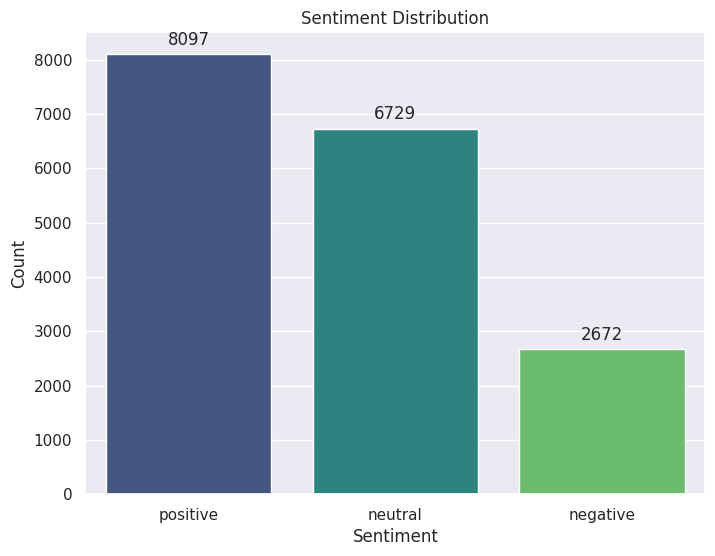

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'sentiment' is the column name in your DataFrame
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Adding annotations
for i, count in enumerate(sentiment_counts):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=12)

plt.show()


In [173]:
data = df.copy()
data.head()

,date,time,tweet,day_of_week,hour,sentiment
0,01/09/2022,10:09:46,#workathome #digitalnomad #WFH DevOps Enginee...,Thursday,10.150000,negative
1,01/09/2022,10:09:42,Neurobiology: Wellspring of Machine Learning w...,Thursday,10.150000,positive
2,01/09/2022,10:08:58,Opening for remote Lead Flask Developer with P...,Thursday,10.133333,negative
3,01/09/2022,10:08:22,Bytesview's advanced #textanalysis tools let y...,Thursday,10.133333,positive
5,01/09/2022,10:07:51,Opening for remote Seeking Django Developer wi...,Thursday,10.116667,negative


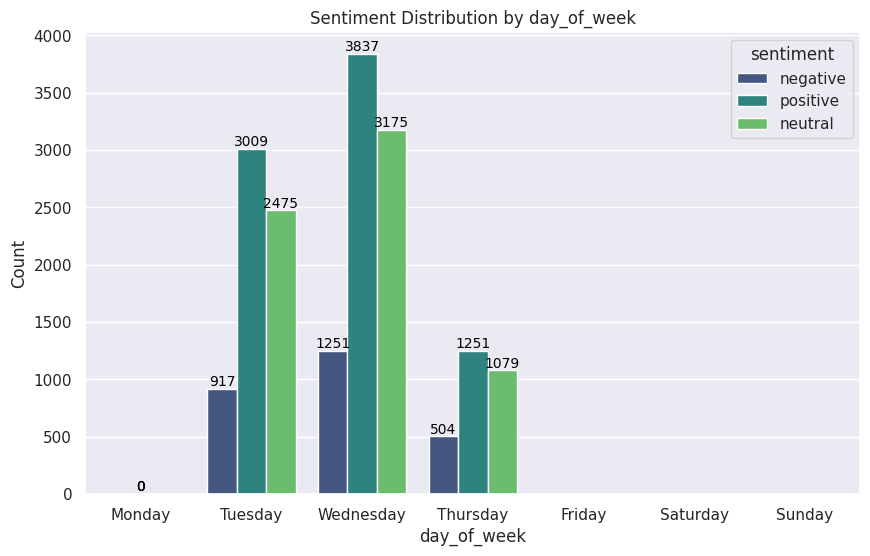

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

# 'day_of_week' is a column in our Dataframe
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cat_type = CategoricalDtype(categories=cats, ordered=True)

data['day_of_week'] = data['day_of_week'].astype(cat_type)

def labeled_barplot(df, feature, target):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue=target, palette="viridis")
    plt.title(f'Sentiment Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title=target, title_fontsize='12')

    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                           textcoords='offset points')

    plt.show()

# Assuming 'sentiment' is the column ywe want to analyse
labeled_barplot(data, 'day_of_week', 'sentiment')


How would you describe this?

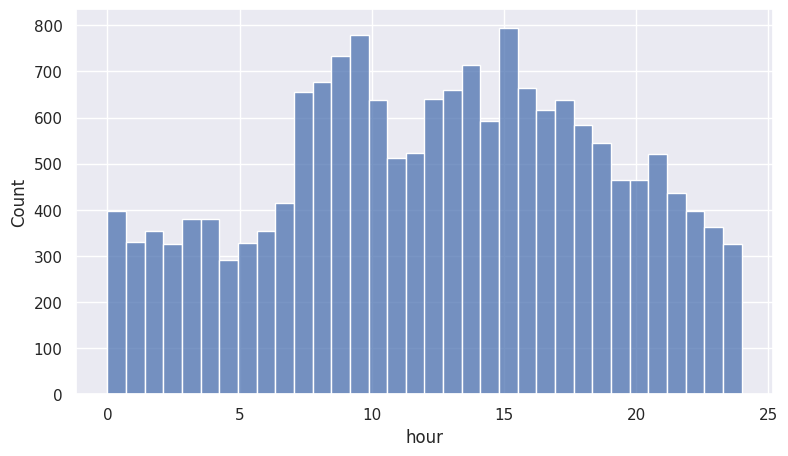

In [175]:
# hour

plt.figure(figsize=(9,5))
sns.histplot(data=data, x='hour');

- Majority of the tweets are in the mid-morning late afternoons (peaking after 3PM)

New features will be created by counting number of positive & negative words in each tweet. The list of all positive & negative words are borrowed from this study: https://www.cs.uic.edu/~liub/FBS/sentiment-analysis.html

In [176]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [177]:
import pandas as pd
positive_words =pd.read_csv('/content/drive/MyDrive/positive-words.txt',skiprows=35, names=['words'])
positive_words = positive_words['words'].values.tolist()

In [178]:
import pandas as pd
negative_words =pd.read_csv('/content/drive/MyDrive/negative-words.txt',skiprows=35, names=['words'])
negative_words = negative_words['words'].values.tolist()

In [180]:
# Let's create new features, i.e., number of positive & negative words associated with each text

# Defining a function to count number of positive & negative words

def count_words(tweet, words):
    count = 0
    for word in tweet.split(' '):
        if word in words:
            count += 1
    return count

data['number_positive_words'] = data['tweet'].apply(count_words, words=positive_words)
data['number_negative_words'] = data['tweet'].apply(count_words, words=negative_words)

In [182]:
# Function to create stacked barplots

def stacked_barplot(data, predictor, target):

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(by=sorter, ascending=False)
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(by=predictor, ascending=True)
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(loc="lower left", frameon=False,)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

sentiment              negative  neutral  positive    All
number_positive_words                                    
All                        2672     6729      8097  17498
0                          2058     6076      4555  12689
1                           439      532      2283   3254
2                           136       96       908   1140
3                            25       19       251    295
4                            12        5        64     81
5                             1        1        24     26
6                             1        0        10     11
7                             0        0         2      2
------------------------------------------------------------------------------------------------------------------------


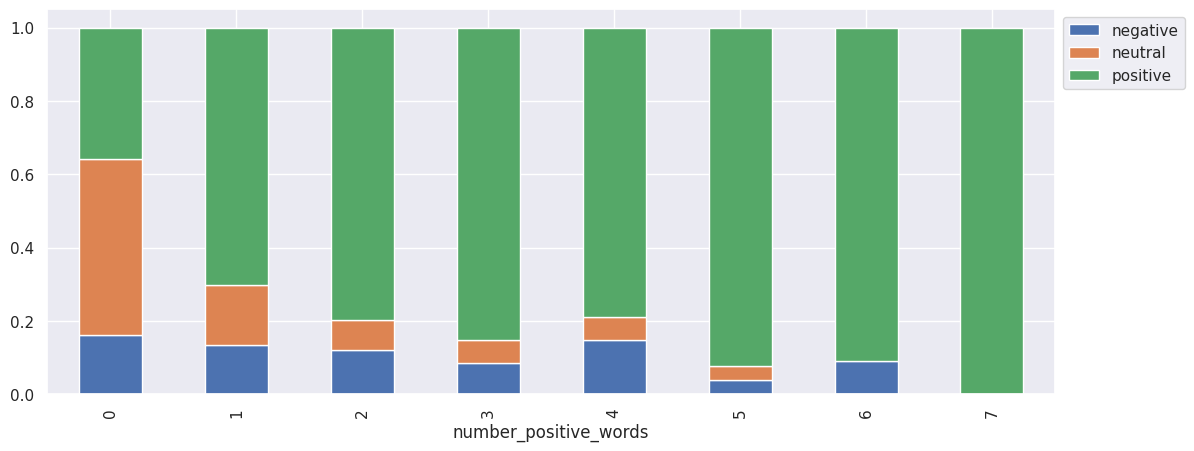

In [183]:
# number_positive_words

stacked_barplot(data, 'number_positive_words', 'sentiment')

- Tweets with 0 or 1 count for number_positive_words have all three sentiments 'neutral', 'positive' & 'negative'
- Tweets with 1, 2, 3 or 4 number_positive_words are majorly a 'positive' sentiment as expected

sentiment              negative  neutral  positive    All
number_negative_words                                    
All                        2672     6729      8097  17498
0                          2146     6320      6999  15465
1                           362      360       906   1628
2                           134       40       160    334
3                            24        6        25     55
4                             3        2         5     10
5                             2        1         1      4
6                             1        0         1      2
------------------------------------------------------------------------------------------------------------------------


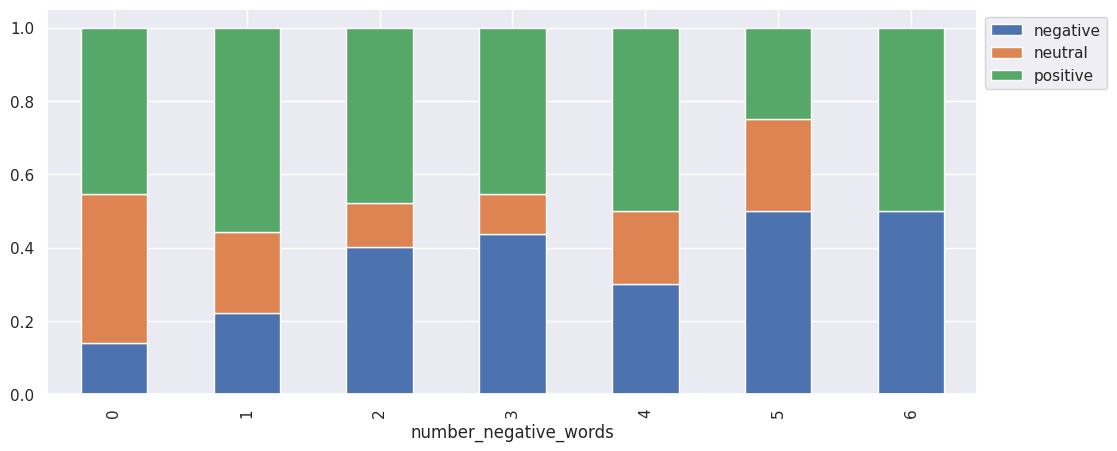

In [184]:
# number_negative_words

stacked_barplot(data, 'number_negative_words', 'sentiment')

- Tweets with 0 or 1 count for number_negative_words have all three sentiments 'neutral', 'positive' & 'negative'
- Apart from 4 - the more negatiev words the tweet has the gigher the neative sentiment, as expected. But do you think 4 is different?

**WORD CLOUD**

In [ ]:
data.head()

,date,time,tweet,day_of_week,hour,sentiment,number_positive_words,number_negative_words
0,01/09/2022,10:09:46,#workathome #digitalnomad #WFH DevOps Enginee...,Thursday,10.150000,negative,0,0
1,01/09/2022,10:09:42,Neurobiology: Wellspring of Machine Learning w...,Thursday,10.150000,positive,1,0
2,01/09/2022,10:08:58,Opening for remote Lead Flask Developer with P...,Thursday,10.133333,negative,0,0
3,01/09/2022,10:08:22,Bytesview's advanced #textanalysis tools let y...,Thursday,10.133333,positive,2,0
5,01/09/2022,10:07:51,Opening for remote Seeking Django Developer wi...,Thursday,10.116667,negative,0,0


We see tweets have upper and lower case.

In [ ]:
# Convert tweets to lowercase

data['tweet'] = data['tweet'].str.lower()

# Remove non-alphanumeric character from tweets such as '@'

def remove_non_alphanumeric(tweet):
    pattern = re.compile('\W')
    x = re.sub(pattern, ' ', tweet)
    return(x)

data['tweet'] = data['tweet'].apply(remove_non_alphanumeric)

data.head()

,date,time,tweet,day_of_week,hour,sentiment,number_positive_words,number_negative_words
0,01/09/2022,10:09:46,workathome digitalnomad wfh devops enginee...,Thursday,10.150000,negative,0,0
1,01/09/2022,10:09:42,neurobiology wellspring of machine learning w...,Thursday,10.150000,positive,1,0
2,01/09/2022,10:08:58,opening for remote lead flask developer with p...,Thursday,10.133333,negative,0,0
3,01/09/2022,10:08:22,bytesview s advanced textanalysis tools let y...,Thursday,10.133333,positive,2,0
5,01/09/2022,10:07:51,opening for remote seeking django developer wi...,Thursday,10.116667,negative,0,0


- The text has been converted to lowercase & non-alphanumerical characters such as @ & # have been removed

In [185]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [186]:
# Tokenize sentences to arrays of words

data['tokens'] = data['tweet'].apply(nltk.word_tokenize)

data.head()

,date,time,tweet,day_of_week,hour,sentiment,number_positive_words,number_negative_words,tokens
0,01/09/2022,10:09:46,#workathome #digitalnomad #WFH DevOps Enginee...,Thursday,10.150000,negative,0,0,"[#, workathome, #, digitalnomad, #, WFH, DevOp..."
1,01/09/2022,10:09:42,Neurobiology: Wellspring of Machine Learning w...,Thursday,10.150000,positive,1,0,"[Neurobiology, :, Wellspring, of, Machine, Lea..."
2,01/09/2022,10:08:58,Opening for remote Lead Flask Developer with P...,Thursday,10.133333,negative,0,0,"[Opening, for, remote, Lead, Flask, Developer,..."
3,01/09/2022,10:08:22,Bytesview's advanced #textanalysis tools let y...,Thursday,10.133333,positive,2,0,"[Bytesview, 's, advanced, #, textanalysis, too..."
5,01/09/2022,10:07:51,Opening for remote Seeking Django Developer wi...,Thursday,10.116667,negative,0,0,"[Opening, for, remote, Seeking, Django, Develo..."


In [187]:
# Lemmatize the words
 #Lemmatisation is the process of reducing words to their base or dictionary form (known as a lemma), considering the word's meaning and context. The result is always a valid word in the language.

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
lem = WordNetLemmatizer()
data['tokens'] = data['tokens'].apply(lambda x: [lem.lemmatize(word) for word in x])

data.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,date,time,tweet,day_of_week,hour,sentiment,number_positive_words,number_negative_words,tokens
0,01/09/2022,10:09:46,#workathome #digitalnomad #WFH DevOps Enginee...,Thursday,10.150000,negative,0,0,"[#, workathome, #, digitalnomad, #, WFH, DevOp..."
1,01/09/2022,10:09:42,Neurobiology: Wellspring of Machine Learning w...,Thursday,10.150000,positive,1,0,"[Neurobiology, :, Wellspring, of, Machine, Lea..."
2,01/09/2022,10:08:58,Opening for remote Lead Flask Developer with P...,Thursday,10.133333,negative,0,0,"[Opening, for, remote, Lead, Flask, Developer,..."
3,01/09/2022,10:08:22,Bytesview's advanced #textanalysis tools let y...,Thursday,10.133333,positive,2,0,"[Bytesview, 's, advanced, #, textanalysis, too..."
5,01/09/2022,10:07:51,Opening for remote Seeking Django Developer wi...,Thursday,10.116667,negative,0,0,"[Opening, for, remote, Seeking, Django, Develo..."


- We can see examples of words being broken down to the root  

In [188]:
# Stemming the words:
#Stemming is the process of removing suffixes or prefixes from a word to obtain its base or root form, which may not be a valid word in the language.

stem = PorterStemmer()
data['tokens'] = data['tokens'].apply(lambda x: [stem.stem(word) for word in x])

data['tokens'] = data['tokens'].str.join(' ')

data.head()

,date,time,tweet,day_of_week,hour,sentiment,number_positive_words,number_negative_words,tokens
0,01/09/2022,10:09:46,#workathome #digitalnomad #WFH DevOps Enginee...,Thursday,10.150000,negative,0,0,# workathom # digitalnomad # wfh devop engin -...
1,01/09/2022,10:09:42,Neurobiology: Wellspring of Machine Learning w...,Thursday,10.150000,positive,1,0,neurobiolog : wellspr of machin learn with pro...
2,01/09/2022,10:08:58,Opening for remote Lead Flask Developer with P...,Thursday,10.133333,negative,0,0,open for remot lead flask develop with python ...
3,01/09/2022,10:08:22,Bytesview's advanced #textanalysis tools let y...,Thursday,10.133333,positive,2,0,bytesview 's advanc # textanalysi tool let you...
5,01/09/2022,10:07:51,Opening for remote Seeking Django Developer wi...,Thursday,10.116667,negative,0,0,open for remot seek django develop with javasc...


- We can see examples of words being broken down to root (irrespective of the tense) like opening has become open; seeking becamse seek - a few odd ones too.

In [189]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import pandas as pd
old_data=pd.read_csv('/content/drive/MyDrive/ai2.csv')

Mounted at /content/drive


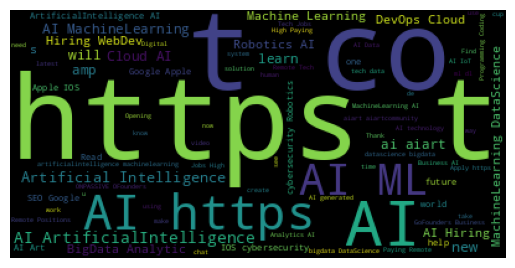

In [190]:
# Let's plot a word cloud to see the difference between original tweets & tweets post data cleaning

# Original tweets


old_data['tweet'].to_csv('tweetsonly.csv')
text2 = open('tweetsonly.csv').read()

wordcloud = WordCloud().generate(text2)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

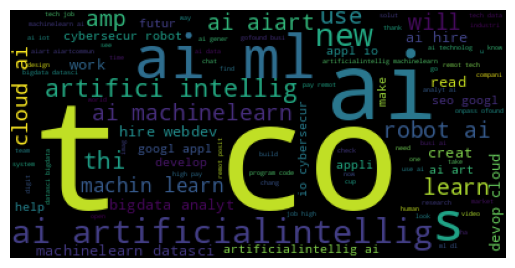

In [191]:
# tweets post data cleaning

data['tokens'].to_csv('cleanedtweetsonly.csv')
text3 = open('cleanedtweetsonly.csv').read()

wordcloud = WordCloud().generate(text3)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


- 'HTTPS' was a common occurrence in the original tweets but is no longer a common occurrence in cleaned up tweets. Anything else?

In [192]:
# Dropping tweet column

data = data.drop('tweet', axis=1)

### Machine Learning

In [193]:
data['sentiment'] = data['sentiment'].replace({'neutral':0, 'positive':1, 'negative':-1})
data['sentiment'] = data['sentiment'].astype(int)

In [194]:
# Assign features & target as X & y respectively

X = data.drop('sentiment', axis=1)
y = data['sentiment']

In [195]:
# One hot encoding of day_of_week column

X = pd.get_dummies(X, columns=['day_of_week'], drop_first=True)

In [196]:
# Split data into train & test set using stratify to maintain the split of sentiment across train & test sets

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y,\
                                                   shuffle=True)

In [197]:
# Shape of splits

X_train_full.shape

(13998, 12)

In [198]:
X_test.shape

(3500, 12)

- There are now 8 columns & 13936 and 3485 rows respectively in full training & test sets

In [199]:
y_train_full.value_counts(normalize=True)

,proportion
sentiment,
1,0.462709
0,0.384555
-1,0.152736


In [200]:
y_test.value_counts(normalize=True)

,proportion
sentiment,
1,0.462857
0,0.384571
-1,0.152571


- Stratify has maintained the split of neutral ('0'), positive ('1') & negative ('-1') tweets in the dataset

We would like each class to be predicted correctly. Tuning the 'F1' metric will ensure the maximum possibility of correct predictions across each of the target classes

Further, the following additional points need consideration

- Vectorizer 'TFIDF' is chosen to convert text data to numerical feature matrix
- RandomOverSampler would be needed to handle class imbalance across target classes
- Further, choice of ML model(s) that work well with textual data- Multinomial Naive Baiyes, Linear Support Vector Classifier, Random Forest Classifier & XGBoost
